# 2 mmini-models made with math


## 1 regression model


In [1]:
import sympy as sp

w, b = sp.symbols('w, b')
x_data = [1, 2, 3, 4, 5]
y_data = [15, 25, 30, 42, 50]

C = sum((w * xv + b - yv) ** 2 for xv, yv in zip(x_data, y_data)) / len(x_data)

print(sp.expand(C)) # b**2 + 6*b*w - 324*b/5 + 11*w**2 - 1146*w/5 + 6014/5

b**2 + 6*b*w - 324*b/5 + 11*w**2 - 1146*w/5 + 6014/5


In [2]:
dC_dw = sp.diff(C, w)
dC_db = sp.diff(C, b)

print(dC_dw)
print(dC_db)

print(float(dC_dw.subs({w: 0 , b: 0})), float(dC_db.subs({w: 0 , b: 0})))

6*b + 22*w - 1146/5
2*b + 6*w - 324/5
-229.2 -64.8


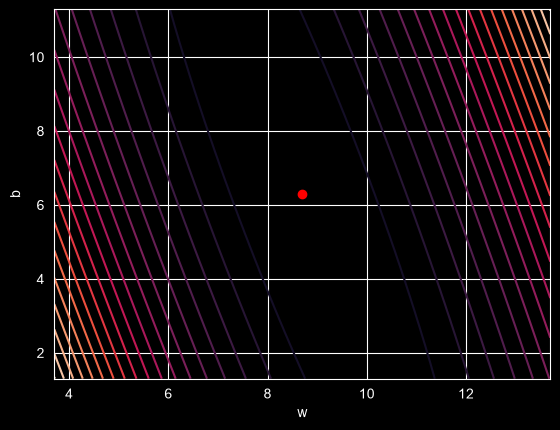

In [3]:
# 3 step: cost func visualization

import numpy as np
import matplotlib.pyplot as plt

cost = sp.lambdify((w, b), C, 'numpy')
sol = sp.solve([dC_dw, dC_db], [w, b])

w_opt, b_opt = float(sol[w]), float(sol[b])

W, B = np.meshgrid(
    np.linspace(w_opt - 5, w_opt + 5, 100),
    np.linspace(b_opt - 5, b_opt + 5, 100),
)

plt.contour(W, B, cost(W, B), 20)
plt.scatter([w_opt], [b_opt], color='red')
plt.xlabel('w')
plt.ylabel('b')
plt.show()

In [14]:
# 4 step: gradient descentni ishga tushiramiz

x = np.array([1, 2, 3, 4, 5])
y = np.array([15, 25, 30, 42, 50])
w, b = 0, 0

lr = 0.02

for step in range(2000):
    pred = w * x + b
    dCdw = np.mean(2 * (pred - y) * x)
    dCdb = np.mean(2 * (pred - y))

    # update
    w = w - lr * dCdw
    b = b - lr * dCdb

print(f"w: {w}, b: {b}, cost = ", cost(w, b))

w: 8.700000000000026, b: 6.299999999999911, cost =  1.6600000000000021


In [13]:
# 6 step

w, b = sp.symbols('w b')
C = sum((w * xv + b - yv) ** 2 for xv, yv in zip(x_data, y_data)) / len(x_data)

sol = sp.solve([sp.diff(C, w), sp.diff(C, b)], [w, b])


{b: 63/10, w: 87/10}


# Task A

In [92]:
x = [2, 4, 6, 7, 8, 9, 10]
y = [52, 54, 56, 67, 78, 86, 94]

# 1)
w, b = sp.symbols('w, b')

C = sum((w * xv + b - yv) ** 2 for xv, yv in zip(x, y)) / len(x)


dC_dw = sp.diff(C, w)
dC_db = sp.diff(C, b)

print(dC_dw)
print(dC_db)

# 2)
sol = sp.solve([sp.diff(C, w), sp.diff(C, b)], [w, b])
print(sol)

# 3)
lr = 0.01
w, b = 0, 0
x = np.array([2, 4, 6, 7, 8, 9, 10])
y = np.array([52, 54, 56, 67, 78, 86, 94])

for step in range(43):
    pred = w * x + b
    dCdw = np.mean(2 * (pred - y) * x)
    dCdb = np.mean(2 * (pred - y))
    w = w - lr * dCdw
    b = b - lr * dCdb
print(f"w: {w}, b: {b}, cost = ", cost(w, b))

92*b/7 + 100*w - 6926/7
2*b + 92*w/7 - 974/7
{b: 5576/167, w: 1839/334}
w: 9.275846278046119, b: 4.782392971494212, cost =  2.367269234895287


## 2 classification model

In [93]:
# 1 step
z = sp.symbols("z")
sigmoid = 1 / (1 + sp.exp(-z))
d_sigmoid = sp.diff(sigmoid, z)

print(sp.simplify(d_sigmoid))
print(sp.simplify(d_sigmoid - sigmoid * (1 - sigmoid)))


1/(4*cosh(z/2)**2)
0


In [96]:
# 2 step
w, x, y, b = sp.symbols("w x y b")

p = 1 / (1 + sp.exp(-(w * x + b)))

Loss = - (y * sp.log(p) + (1 - y) * sp.log(1 - p)) # binary cross-entropy
dLoss_dw = sp.diff(Loss, w)
print(sp.simplify(dLoss_dw - (p - y) * x))

0


In [ ]:
# 3 step training logistic regression
def sigmoid(z): return 1 / (1 + sp.exp(-z))
x = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y = np.array([0, 0, 0, 1, 0, 1, 1, 1])

w, b, lr = 0, 0, 0.1

for step in range(2000):
    p = sigmoid(w * x + b)
    dw = np.mean((p - y) * x)
    db = np.mean((p - y))

    w, b = w - lr * dw, b - lr * db

print(f"w: {w}, b: {b}")
print(np.round(sigmoid(w * x + b), 3))

In [ ]:
# 4 step
p = sigmoid(w * x + b)
tpr, fpr = [0, 0], [0, 0]

for t in np.sort(np.unique(p))[::-1]:
    pred = (p >= t).astype(int)
    tpr.append(np.sum((pred == 1) & (y == 1)) / np.sum(y == 1))
    fpr.append(np.sum((pred == 1) & (y == 0)) / np.sum(y == 0))

auc = np.trapezoid(tpr, fpr)
print(f"AUC: {auc}")